In [1]:
! pip install flaml
! pip install "flaml[automl]"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

| Feature          | Description                                        |
|-----------------|----------------------------------------------------|
| Airline          | The name of the airline.                           |
| Date_of_Journey  | The date of the journey.                           |
| Source           | The source from which the service begins.         |
| Destination      | The destination where the service ends.           |
| Route            | The route taken by the flight to reach destination.|
| Dep_Time         | The time when the journey starts from the source. |
| Arrival_Time     | Time of arrival at the destination.               |
| Duration         | Total duration of the flight.                     |
| Total_Stops      | Total stops between the source and destination.   |
| Additional_Info  | Additional information about the flight.          |
| Price            | The price of the ticket.                           |


In [3]:
df1=pd.read_csv("/kaggle/input/flightdata/flight data.csv")
df2=pd.read_csv("/kaggle/input/flightdata/flight test.csv")

In [4]:
df=pd.concat([df1,df2],ignore_index=True)

In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0


In [6]:
df.shape

(13354, 11)

In [7]:
df.isnull().sum()

Airline               0
Date_of_Journey       0
Source                0
Destination           0
Route                 1
Dep_Time              0
Arrival_Time          0
Duration              0
Total_Stops           1
Additional_Info       0
Price              2671
dtype: int64

In [8]:
df['Price'].fillna(df['Price'].mean(), inplace=True)
df["Total_Stops"].fillna(df["Total_Stops"].mode()[0],inplace=True)

In [9]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13354 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            13354 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


In [11]:
df.describe()

,Price
count,13354.000000
mean,9087.064121
std,4124.447805
min,1759.000000
25%,6135.250000
50%,9087.064121
75%,11087.000000
max,79512.000000


In [12]:
df['Date']=df['Date_of_Journey'].str.split('/').str[0]
df['Month']=df['Date_of_Journey'].str.split('/').str[1]
df['Year']=df['Date_of_Journey'].str.split('/').str[2]
df['Date']=df['Date'].astype(int)
df['Month']=df['Month'].astype(int)
df['Year']=df['Year'].astype(int)

In [13]:
df.drop(columns=["Date_of_Journey"],axis=1,inplace=True)

In [14]:
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M %d %b', errors='coerce')

In [15]:
def fill_arrival_time(row):
    if pd.isna(row['Arrival_Time']):
        try:
            # Split duration into hours and minutes
            dur = row['Duration']
            dur = dur.replace('h', '').replace('m', '')
            if ' ' in dur:
                hours, minutes = map(int, dur.split())
            else:
                hours, minutes = (int(dur), 0) if 'h' in row['Duration'] else (0, int(dur))
            
            # Convert Dep_Time to datetime
            dep_hour, dep_minute = map(int, row['Dep_Time'].split(':'))
            arrival_hour = (dep_hour + hours + (dep_minute + minutes)//60) % 24
            arrival_minute = (dep_minute + minutes) % 60
            return pd.Timestamp(year=row['Year'], month=row['Month'], day=row['Date'], hour=arrival_hour, minute=arrival_minute)
        except:
            return pd.NaT
    else:
        return row['Arrival_Time']

df['Arrival_Time'] = df.apply(fill_arrival_time, axis=1)

# Extract features
df['Arrival_Hour'] = df['Arrival_Time'].dt.hour
df['Arrival_Minute'] = df['Arrival_Time'].dt.minute
df['Arrival_Total_Minutes'] = df['Arrival_Hour']*60 + df['Arrival_Minute']

# Categorize time of day
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Arrival_Period'] = df['Arrival_Hour'].apply(time_of_day)

In [16]:
df.drop(columns=["Arrival_Time"],axis=1,inplace=True)

In [17]:
splits = df['Route'].str.split('→ ')
df['Route_1'] = splits.str[0].fillna('None')
df['Route_2'] = splits.str[1].fillna('None')
df['Route_3'] = splits.str[2].fillna('None')
df['Route_4'] = splits.str[3].fillna('None')
df['Route_5'] = splits.str[4].fillna('None')


In [18]:
df.drop(columns=['Route'], inplace=True)

In [19]:
df.head()

,Airline,Source,Destination,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Arrival_Total_Minutes,Arrival_Period,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,22:20,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10,70,Night,BLR,DEL,None,None,None
1,Air India,Kolkata,Banglore,05:50,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15,795,Afternoon,CCU,IXR,BBI,BLR,None
2,Jet Airways,Delhi,Cochin,09:25,19h,2 stops,No info,13882.0,9,6,2019,4,25,265,Night,DEL,LKO,BOM,COK,None
3,IndiGo,Kolkata,Banglore,18:05,5h 25m,1 stop,No info,6218.0,12,5,2019,23,30,1410,Night,CCU,NAG,BLR,None,None
4,IndiGo,Banglore,New Delhi,16:50,4h 45m,1 stop,No info,13302.0,1,3,2019,21,35,1295,Night,BLR,NAG,DEL,None,None


In [20]:
df["Total_Stops"].value_counts()

Total_Stops
1 stop      7057
non-stop    4340
2 stops     1899
3 stops       56
4 stops        2
Name: count, dtype: int64

In [21]:
# Map stops to numeric
def stops_to_num(x):
    if x == 'non-stop':
        return 0
    elif pd.isna(x):
        return -1  # or fill with mode later
    else:
        return int(x.split()[0])  # '1 stop' -> 1, '2 stops' -> 2

df['Total_Stops_Num'] = df['Total_Stops'].apply(stops_to_num)


In [22]:
df.drop(columns=["Total_Stops"],axis=1,inplace=True)

In [23]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         10493
In-flight meal not included      2426
No check-in baggage included      396
1 Long layover                     20
Change airports                     8
Business class                      5
No Info                             3
1 Short layover                     1
Red-eye flight                      1
2 Long layover                      1
Name: count, dtype: int64

In [24]:
# Convert all text to consistent case
df['Additional_Info'] = df['Additional_Info'].str.lower()

# Define frequent categories
frequent_categories = ['no info', 'in-flight meal not included', 'no check-in baggage included']

# Replace rare categories with 'other'
df['Additional_Info_Cat'] = df['Additional_Info'].apply(lambda x: x if x in frequent_categories else 'other')


In [25]:
df.drop(columns=['Additional_Info'], inplace=True)


In [26]:
df.head()

,Airline,Source,Destination,Dep_Time,Duration,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Arrival_Total_Minutes,Arrival_Period,Route_1,Route_2,Route_3,Route_4,Route_5,Total_Stops_Num,Additional_Info_Cat
0,IndiGo,Banglore,New Delhi,22:20,2h 50m,3897.0,24,3,2019,1,10,70,Night,BLR,DEL,None,None,None,0,no info
1,Air India,Kolkata,Banglore,05:50,7h 25m,7662.0,1,5,2019,13,15,795,Afternoon,CCU,IXR,BBI,BLR,None,2,no info
2,Jet Airways,Delhi,Cochin,09:25,19h,13882.0,9,6,2019,4,25,265,Night,DEL,LKO,BOM,COK,None,2,no info
3,IndiGo,Kolkata,Banglore,18:05,5h 25m,6218.0,12,5,2019,23,30,1410,Night,CCU,NAG,BLR,None,None,1,no info
4,IndiGo,Banglore,New Delhi,16:50,4h 45m,13302.0,1,3,2019,21,35,1295,Night,BLR,NAG,DEL,None,None,1,no info


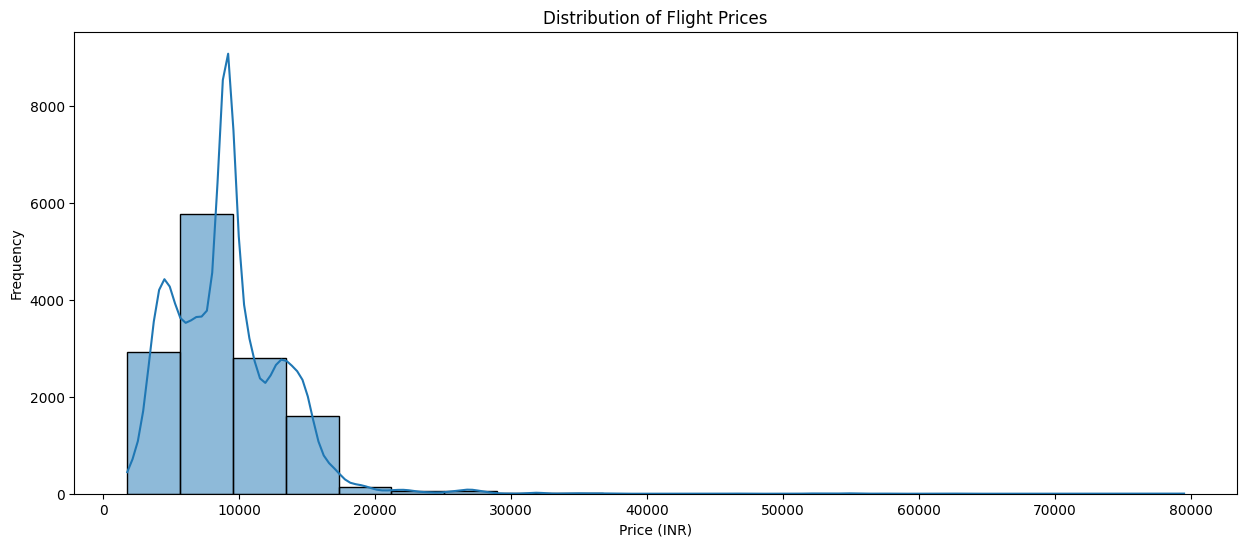

In [27]:
plt.figure(figsize=(15, 6))
sns.histplot(df['Price'], bins=20, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

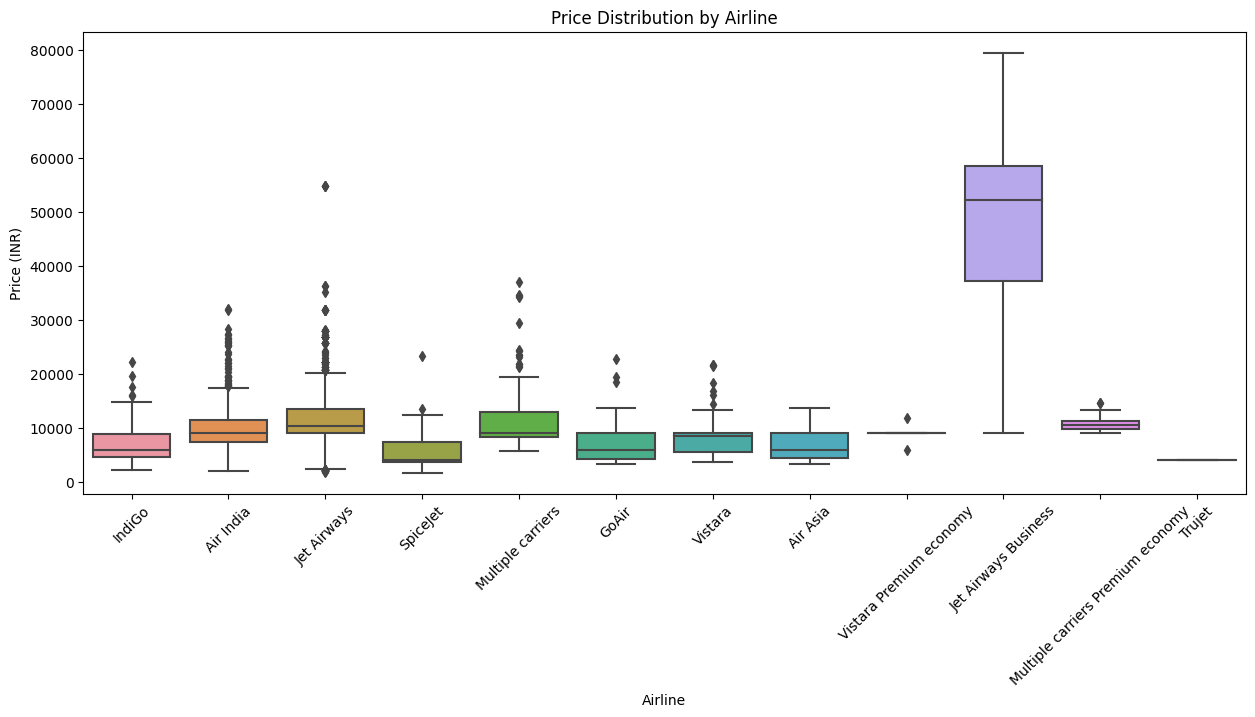

In [28]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.title('Price Distribution by Airline')
plt.xticks(rotation=45)
plt.xlabel('Airline')
plt.ylabel('Price (INR)')
plt.show()

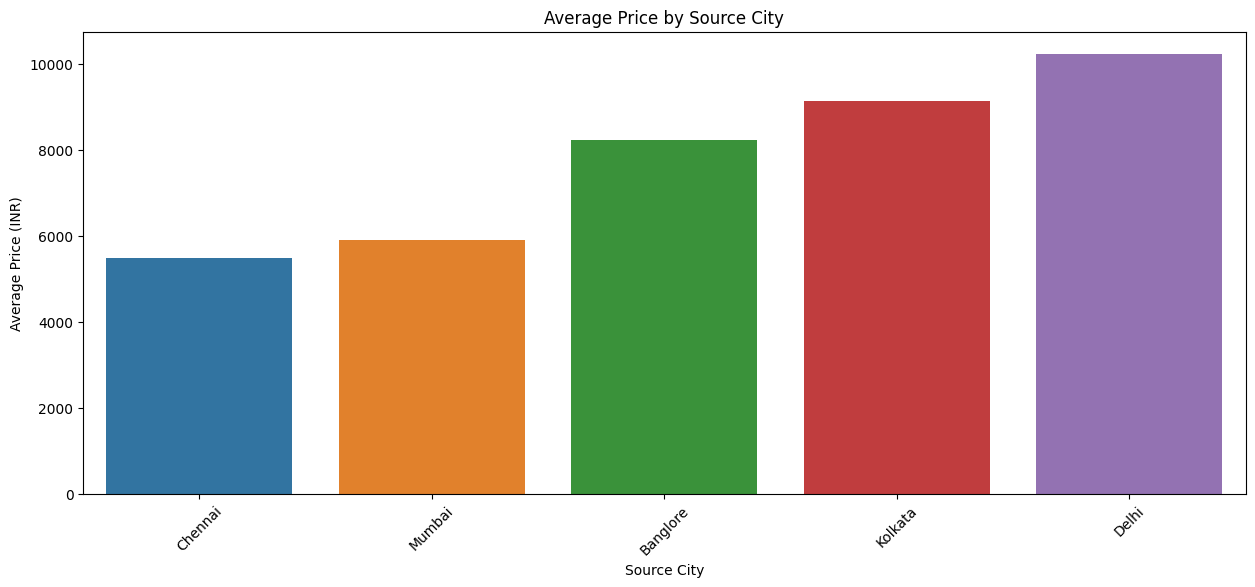

In [29]:
plt.figure(figsize=(15, 6))
avg_price_source = df.groupby('Source')['Price'].mean().sort_values()
sns.barplot(x=avg_price_source.index, y=avg_price_source.values)
plt.title('Average Price by Source City')
plt.xlabel('Source City')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.show()

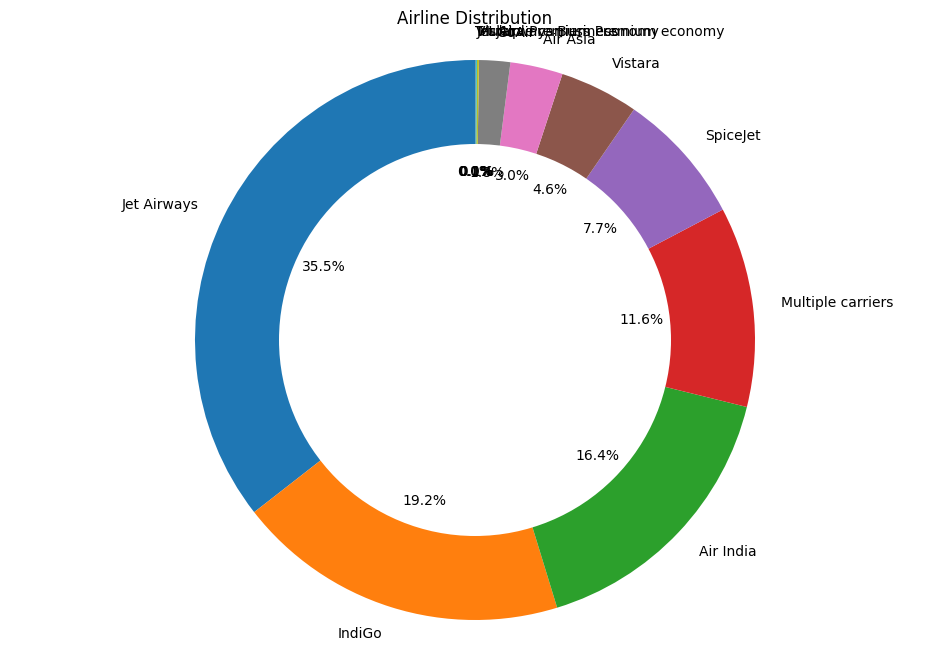

In [30]:
plt.figure(figsize=(12,8))
wedges, texts, autotexts = plt.pie(df['Airline'].value_counts(),labels=df['Airline'].value_counts().index,autopct='%1.1f%%',
    startangle=90)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Airline Distribution')
plt.axis("equal")
plt.show()

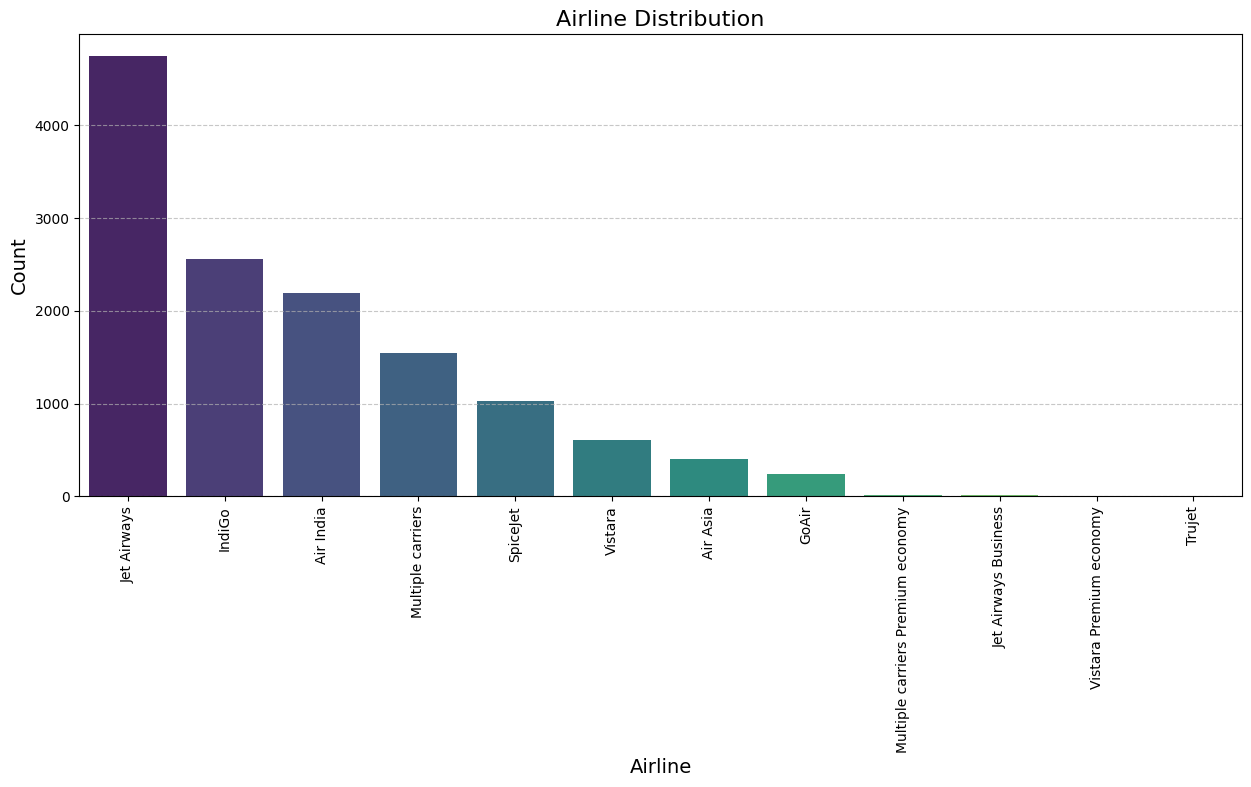

In [31]:

plt.figure(figsize=(15,6))
sns.countplot(data=df, x='Airline', order=df['Airline'].value_counts().index, palette='viridis')

plt.title('Airline Distribution', fontsize=16)
plt.xlabel('Airline', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

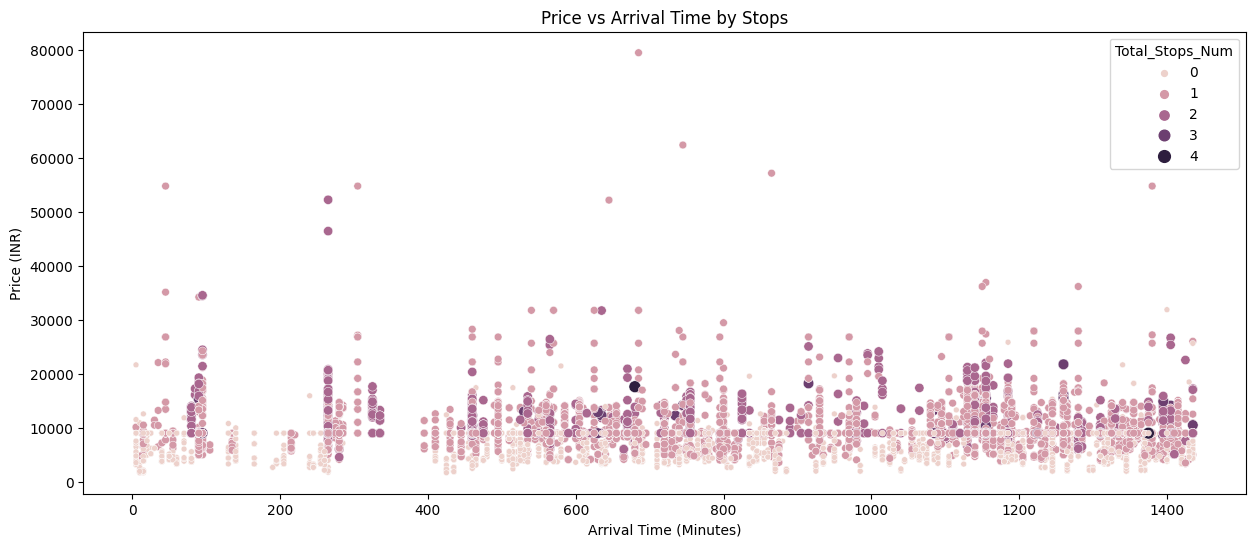

In [32]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='Arrival_Total_Minutes', y='Price', hue='Total_Stops_Num', size='Total_Stops_Num', data=df)
plt.title('Price vs Arrival Time by Stops')
plt.xlabel('Arrival Time (Minutes)')
plt.ylabel('Price (INR)')
plt.show()

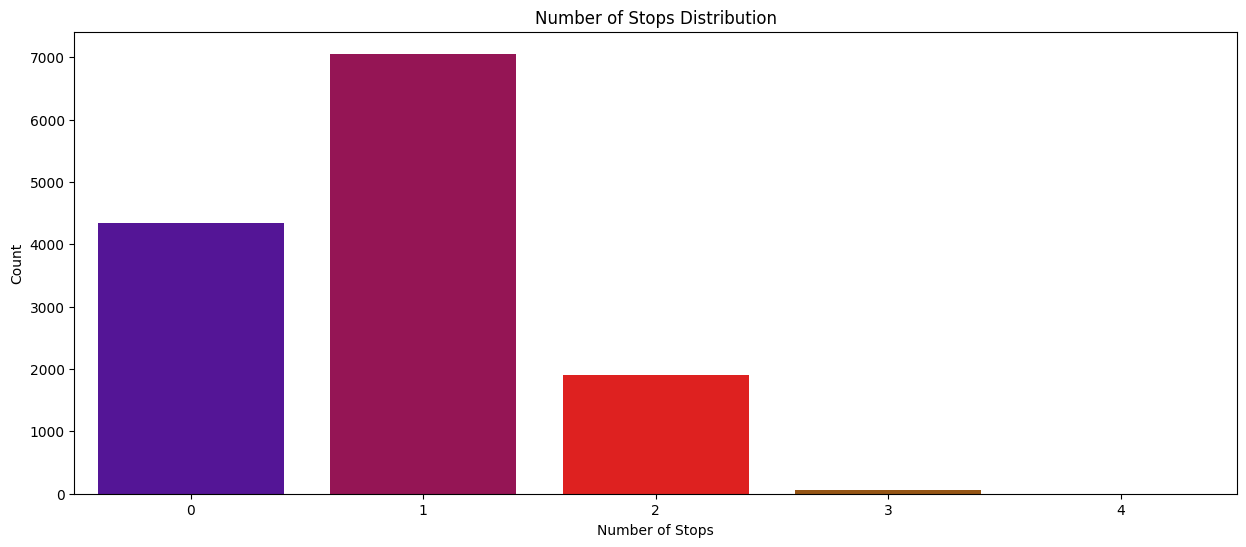

In [33]:
plt.figure(figsize=(15, 6))
sns.countplot(x='Total_Stops_Num', data=df,palette="brg")
plt.title('Number of Stops Distribution')
plt.xlabel('Number of Stops')
plt.ylabel('Count')
plt.show()

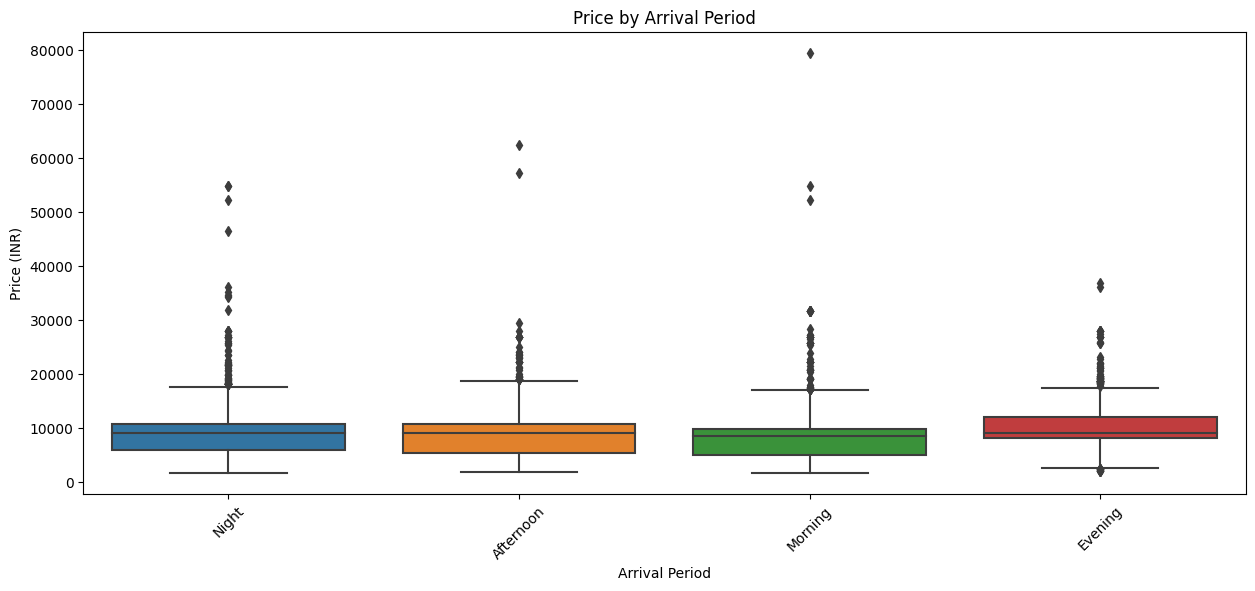

In [34]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Arrival_Period', y='Price', data=df)
plt.title('Price by Arrival Period')
plt.xlabel('Arrival Period')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.show()

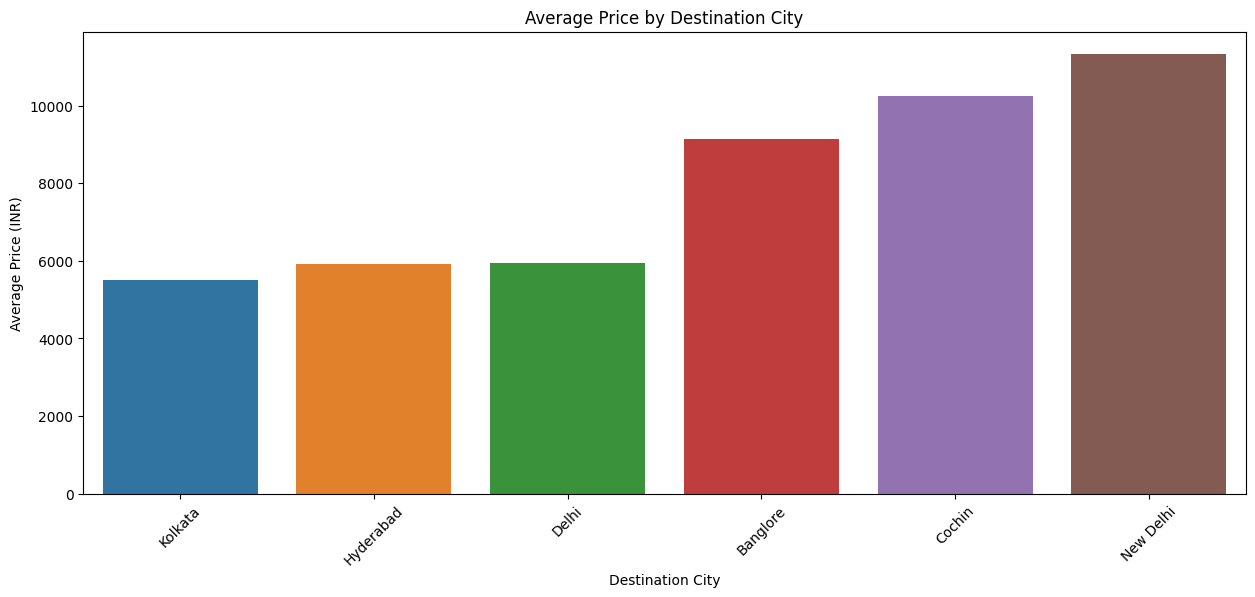

In [35]:
plt.figure(figsize=(15, 6))
avg_price_dest = df.groupby('Destination')['Price'].mean().sort_values()
sns.barplot(x=avg_price_dest.index, y=avg_price_dest.values)
plt.title('Average Price by Destination City')
plt.xlabel('Destination City')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.show()

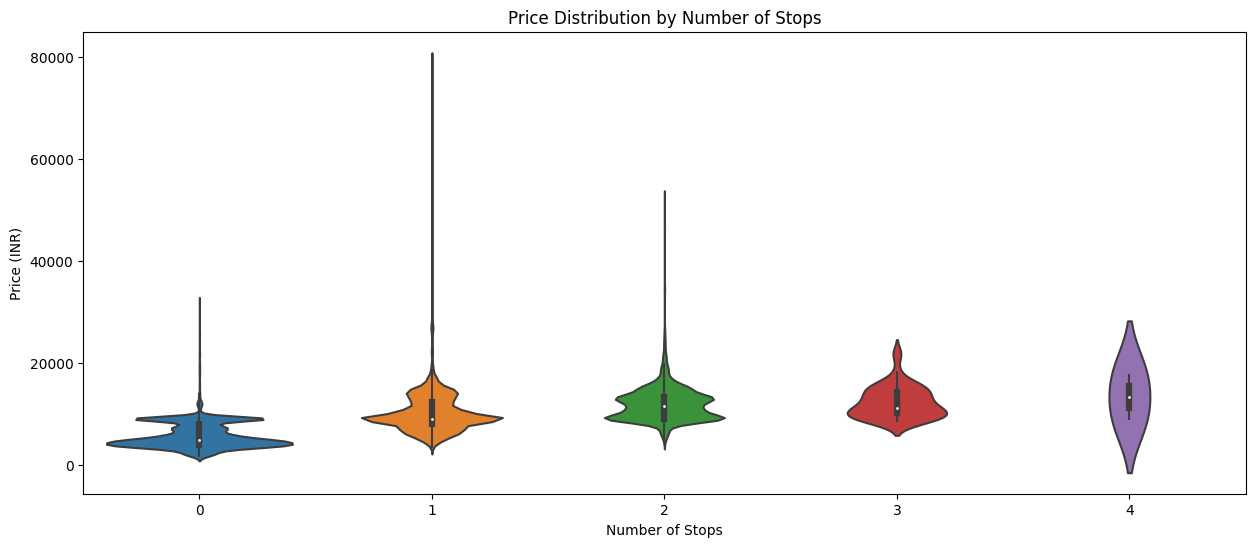

In [36]:
plt.figure(figsize=(15, 6))
sns.violinplot(x='Total_Stops_Num', y='Price', data=df)
plt.title('Price Distribution by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price (INR)')
plt.show()

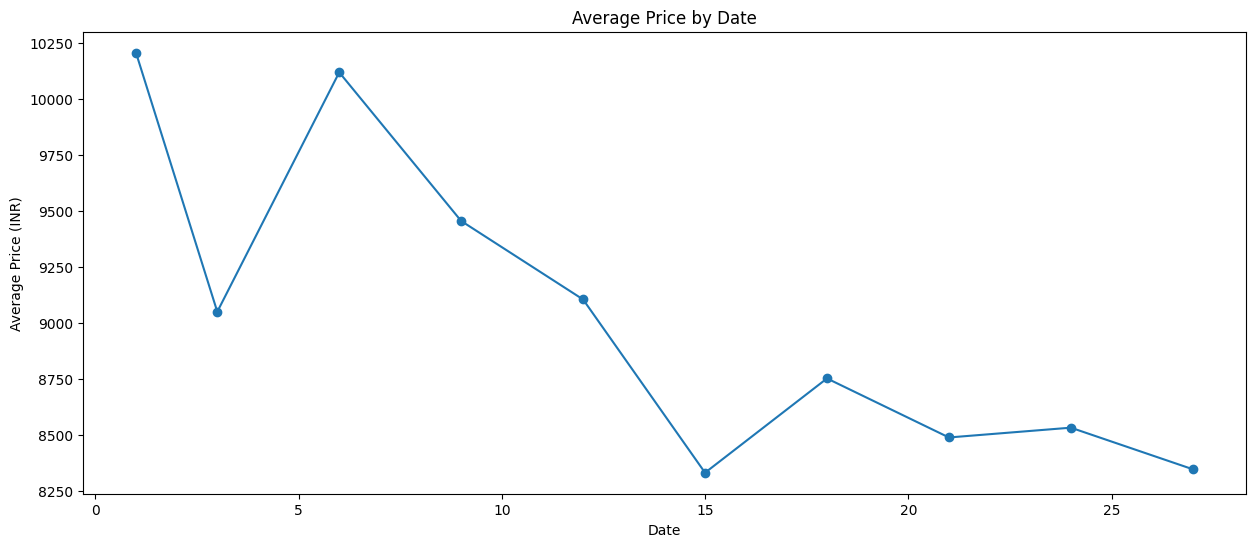

In [37]:
plt.figure(figsize=(15, 6))
avg_price_date = df.groupby('Date')['Price'].mean()
plt.plot(avg_price_date.index, avg_price_date.values, marker='o')
plt.title('Average Price by Date')
plt.xlabel('Date')
plt.ylabel('Average Price (INR)')
plt.show()

In [38]:
import plotly.express as px

fig = px.scatter(
    df, x='Arrival_Total_Minutes', y='Price', color='Airline', size='Total_Stops_Num',
    hover_data=['Source', 'Destination'], title='Price vs Arrival Time by Airline'
)
fig.update_layout(xaxis_title='Arrival Time (Minutes)', yaxis_title='Price (INR)')
fig.show()

In [39]:
avg_price_route = df.groupby(['Source', 'Destination'])['Price'].mean().reset_index()
avg_price_route['Route'] = avg_price_route['Source'] + ' to ' + avg_price_route['Destination']
fig = px.bar(avg_price_route, x='Route', y='Price', title='Average Price by Route')
fig.update_layout(xaxis_title='Route', yaxis_title='Average Price (INR)', xaxis_tickangle=45)
fig.show()

In [40]:
fig = px.box(df, x='Month', y='Price', color='Airline', title='Price Distribution by Month')
fig.update_layout(xaxis_title='Month', yaxis_title='Price (INR)')
fig.show()

In [41]:
fig = px.pie(df, names='Arrival_Period', title='Arrival Period Distribution')
fig.show()

In [42]:
import plotly.graph_objects as go

pivot_table = df.pivot_table(values='Price', index='Source', columns='Destination', aggfunc='mean')
fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values, x=pivot_table.columns, y=pivot_table.index, colorscale='Viridis'
))
fig.update_layout(title='Average Price by Source-Destination', xaxis_title='Destination', yaxis_title='Source')
fig.show()

In [43]:
avg_price_month_airline = df.groupby(['Month', 'Airline'])['Price'].mean().reset_index()
fig = px.line(avg_price_month_airline, x='Month', y='Price', color='Airline', title='Average Price by Month and Airline')
fig.update_layout(xaxis_title='Month', yaxis_title='Average Price (INR)')
fig.show()

In [44]:
# Prepare data for Sankey diagram
nodes = list(set(df['Source']).union(set(df['Destination'])).union(set(df['Route_1'])).union(set(df['Route_2'])).union(set(df['Route_3'])).union(set(df['Route_4'])).union(set(df['Route_5'])))
nodes = [n for n in nodes if n != 'None']
node_dict = {node: i for i, node in enumerate(nodes)}

links = []
for _, row in df.iterrows():
    route_nodes = [row['Route_1'], row['Route_2'], row['Route_3'], row['Route_4'], row['Route_5']]
    route_nodes = [n for n in route_nodes if n != 'None']
    for i in range(len(route_nodes) - 1):
        links.append({
            'source': node_dict[route_nodes[i]],
            'target': node_dict[route_nodes[i + 1]],
            'value': row['Price']
        })

fig = go.Figure(data=go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=nodes
    ),
    link=dict(
        source=[link['source'] for link in links],
        target=[link['target'] for link in links],
        value=[link['value'] for link in links]
    )
))
fig.update_layout(title='Flight Route Flow (Sankey Diagram)')
fig.show()

In [45]:
df.head()

,Airline,Source,Destination,Dep_Time,Duration,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Arrival_Total_Minutes,Arrival_Period,Route_1,Route_2,Route_3,Route_4,Route_5,Total_Stops_Num,Additional_Info_Cat
0,IndiGo,Banglore,New Delhi,22:20,2h 50m,3897.0,24,3,2019,1,10,70,Night,BLR,DEL,None,None,None,0,no info
1,Air India,Kolkata,Banglore,05:50,7h 25m,7662.0,1,5,2019,13,15,795,Afternoon,CCU,IXR,BBI,BLR,None,2,no info
2,Jet Airways,Delhi,Cochin,09:25,19h,13882.0,9,6,2019,4,25,265,Night,DEL,LKO,BOM,COK,None,2,no info
3,IndiGo,Kolkata,Banglore,18:05,5h 25m,6218.0,12,5,2019,23,30,1410,Night,CCU,NAG,BLR,None,None,1,no info
4,IndiGo,Banglore,New Delhi,16:50,4h 45m,13302.0,1,3,2019,21,35,1295,Night,BLR,NAG,DEL,None,None,1,no info


In [46]:

def convert_duration_to_minutes(duration):
    if pd.isnull(duration):
        return np.nan
    duration = duration.strip()
    hours = 0
    minutes = 0
    
    if 'h' in duration:
        hours = int(duration.split('h')[0])
        duration = duration.split('h')[1]
    if 'm' in duration:
        minutes = int(duration.strip().replace('m', ''))
    
    return hours * 60 + minutes

df['Duration_Minutes'] = df['Duration'].apply(convert_duration_to_minutes)

In [47]:
df.drop(columns=['Duration'], inplace=True)

In [48]:
def convert_dep_time(dep_time):
    if pd.isnull(dep_time):
        return pd.Series([np.nan, np.nan, np.nan])
    dep_time = dep_time.strip()
    hour, minute = dep_time.split(':')
    hour = int(hour)
    minute = int(minute)
    total_minutes = hour * 60 + minute
    period = 'Night' if hour < 6 or hour >= 18 else ('Morning' if hour < 12 else 'Afternoon')
    return pd.Series([hour, minute, total_minutes, period])

df[['Dep_Hour', 'Dep_Minute', 'Dep_Total_Minutes', 'Dep_Period']] = df['Dep_Time'].apply(convert_dep_time)

In [49]:
df.drop(columns=['Dep_Time'], inplace=True)

In [50]:
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate

str_cols = df.select_dtypes(include=['object']).columns
mappings = []

for col in str_cols:
    le = LabelEncoder()
    df[col] = df[col].fillna("Missing")
    df[col] = le.fit_transform(df[col])
    mapping_df = pd.DataFrame({
        "Column": col,
        "Category": le.classes_,
        "Code": range(len(le.classes_))
    })
    mappings.append(mapping_df)

mapping_table = pd.concat(mappings, ignore_index=True)
print(tabulate(mapping_table, headers='keys', tablefmt="grid"))


+-----+---------------------+-----------------------------------+--------+
|     | Column              | Category                          |   Code |
+=====+=====================+===================================+========+
|   0 | Airline             | Air Asia                          |      0 |
+-----+---------------------+-----------------------------------+--------+
|   1 | Airline             | Air India                         |      1 |
+-----+---------------------+-----------------------------------+--------+
|   2 | Airline             | GoAir                             |      2 |
+-----+---------------------+-----------------------------------+--------+
|   3 | Airline             | IndiGo                            |      3 |
+-----+---------------------+-----------------------------------+--------+
|   4 | Airline             | Jet Airways                       |      4 |
+-----+---------------------+-----------------------------------+--------+
|   5 | Airline          

In [51]:
df.head()

,Airline,Source,Destination,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Arrival_Total_Minutes,...,Route_3,Route_4,Route_5,Total_Stops_Num,Additional_Info_Cat,Duration_Minutes,Dep_Hour,Dep_Minute,Dep_Total_Minutes,Dep_Period
0,3,0,5,3897.0,24,3,2019,1,10,70,...,24,12,4,0,2,170,22,20,1340,2
1,1,3,0,7662.0,1,5,2019,13,15,795,...,1,3,4,2,2,445,5,50,350,2
2,4,2,1,13882.0,9,6,2019,4,25,265,...,4,5,4,2,2,1140,9,25,565,1
3,3,3,0,6218.0,12,5,2019,23,30,1410,...,3,12,4,1,2,325,18,5,1085,2
4,3,0,5,13302.0,1,3,2019,21,35,1295,...,8,12,4,1,2,285,16,50,1010,0


In [52]:
from sklearn.feature_selection import SelectKBest, f_regression


X = df.drop(columns=['Price'])
y = df['Price']

selector = SelectKBest(score_func=f_regression, k=7)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()].tolist()

new_df = df[selected_features + ['Price']].copy()

new_df.head()

,Date,Month,Route_1,Route_3,Route_4,Total_Stops_Num,Duration_Minutes,Price
0,24,3,0,24,12,0,170,3897.0
1,1,5,2,1,3,2,445,7662.0
2,9,6,3,4,5,2,1140,13882.0
3,12,5,2,3,12,1,325,6218.0
4,1,3,0,8,12,1,285,13302.0


In [53]:
from sklearn.model_selection import train_test_split
X = new_df.drop(columns=['Price'])
y = new_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((10683, 7), (2671, 7), (10683,), (2671,))

In [54]:
from flaml import AutoML
automl_settings = {
    "time_budget": 600,  # 10 minutes
    "metric": "r2",
    "task": "regression",
    "log_file_name": "california.log",
}

automl = AutoML()
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

[flaml.automl.logger: 08-15 14:00:22] {1752} INFO - task = regression
[flaml.automl.logger: 08-15 14:00:22] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 08-15 14:00:22] {1862} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 08-15 14:00:22] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']
[flaml.automl.logger: 08-15 14:00:22] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 08-15 14:00:22] {2417} INFO - Estimated sufficient time budget=1001s. Estimated necessary time budget=9s.
[flaml.automl.logger: 08-15 14:00:22] {2466} INFO -  at 0.2s,	estimator lgbm's best error=0.7762,	best estimator lgbm's best error=0.7762
[flaml.automl.logger: 08-15 14:00:22] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-15 14:00:22] {2466} INFO -  at 0.3s,	estimator lgbm's best error=0.7762,	best estimator lgbm's best error=0.7762
[flaml.automl.logger: 08-15 14:00:

In [55]:
# Best model name
print("Best model type:", automl.best_estimator)

# Best hyperparameters
print("Best hyperparameters:", automl.best_config)

# Best validation score
print("Best validation score:", automl.best_loss)

# All tried models and their scores
print("All model history:")
for record in automl.best_config_per_estimator.values():
    print(record)

Best model type: lgbm
Best hyperparameters: {'n_estimators': 543, 'num_leaves': 12, 'min_child_samples': 9, 'learning_rate': 0.11277268140772108, 'log_max_bin': 10, 'colsample_bytree': 0.5391914605094361, 'reg_alpha': 0.0009765625, 'reg_lambda': 0.07848950118661124}
Best validation score: 0.43021601927116676
All model history:
{'n_estimators': 543, 'num_leaves': 12, 'min_child_samples': 9, 'learning_rate': 0.11277268140772108, 'log_max_bin': 10, 'colsample_bytree': 0.5391914605094361, 'reg_alpha': 0.0009765625, 'reg_lambda': 0.07848950118661124}
{'n_estimators': 11, 'max_features': 1.0, 'max_leaves': 240}
{'n_estimators': 426, 'max_leaves': 399, 'min_child_weight': 128.0, 'learning_rate': 0.08727546789327977, 'subsample': 0.8809985595678514, 'colsample_bylevel': 0.8019310132461411, 'colsample_bytree': 0.6020417921420461, 'reg_alpha': 0.1291150290434832, 'reg_lambda': 2.8188363166246804}
{'n_estimators': 35, 'max_features': 1.0, 'max_leaves': 345}
{'n_estimators': 971, 'max_depth': 7, '

In [56]:
y_test_pred = automl.predict(X_test)


In [57]:
# Compute metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
test_metrics = {
    "R2": r2_score(y_test, y_test_pred),
    "MSE": mean_squared_error(y_test, y_test_pred),
    "RMSE": mean_squared_error(y_test, y_test_pred, squared=False),
    "MAE": mean_absolute_error(y_test, y_test_pred)
}

# Prepare data for tabulate
table = [(metric, round(value, 4)) for metric, value in test_metrics.items()]

# Print nicely
print(tabulate(table, headers=["Metric", "Value"], tablefmt="grid"))

+----------+----------------+
| Metric   |          Value |
+==========+================+
| R2       |    0.5541      |
+----------+----------------+
| MSE      |    8.56048e+06 |
+----------+----------------+
| RMSE     | 2925.83        |
+----------+----------------+
| MAE      | 2014.65        |
+----------+----------------+


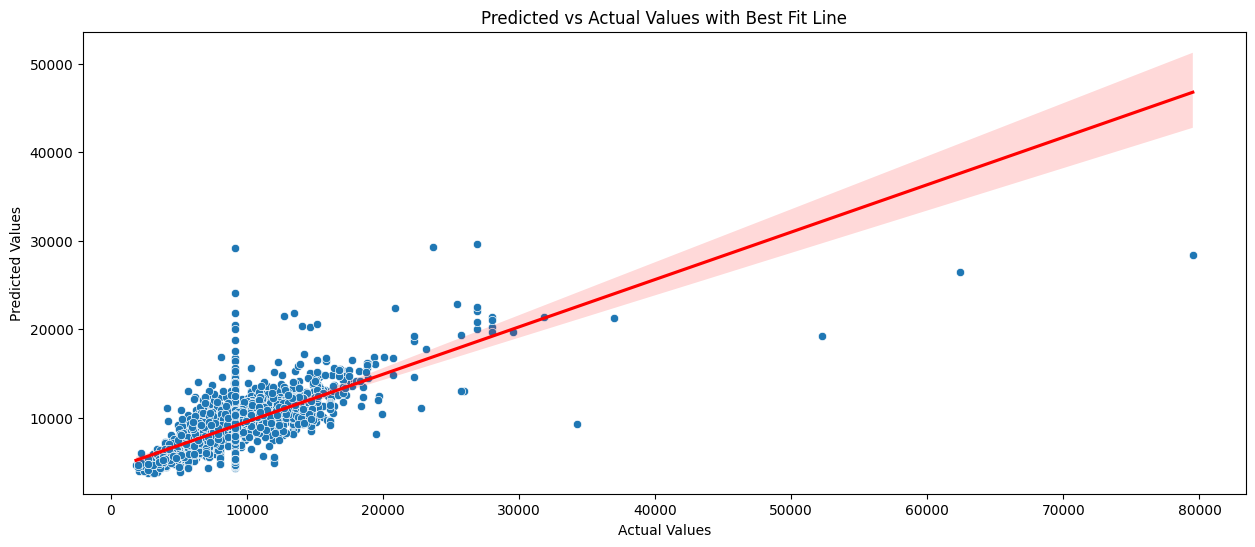

In [58]:
plt.figure(figsize=(15,6))
sns.scatterplot(x=y_test, y=y_test_pred)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color='red')  # Best fit line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values with Best Fit Line")
plt.show()

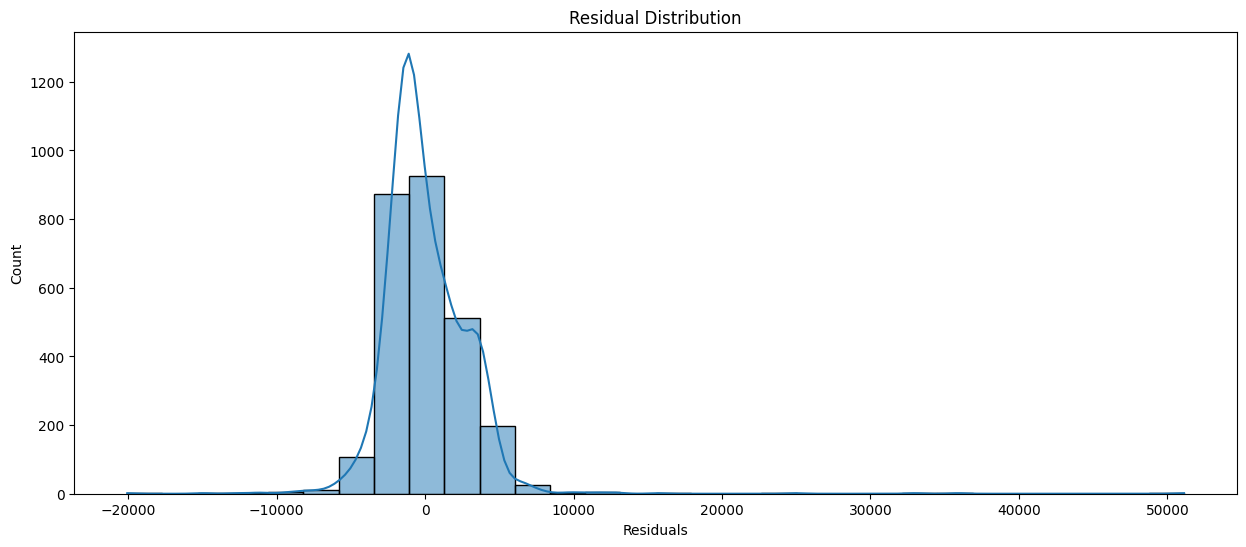

In [59]:
residuals = y_test - y_test_pred
plt.figure(figsize=(15,6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Residual Distribution")
plt.show()

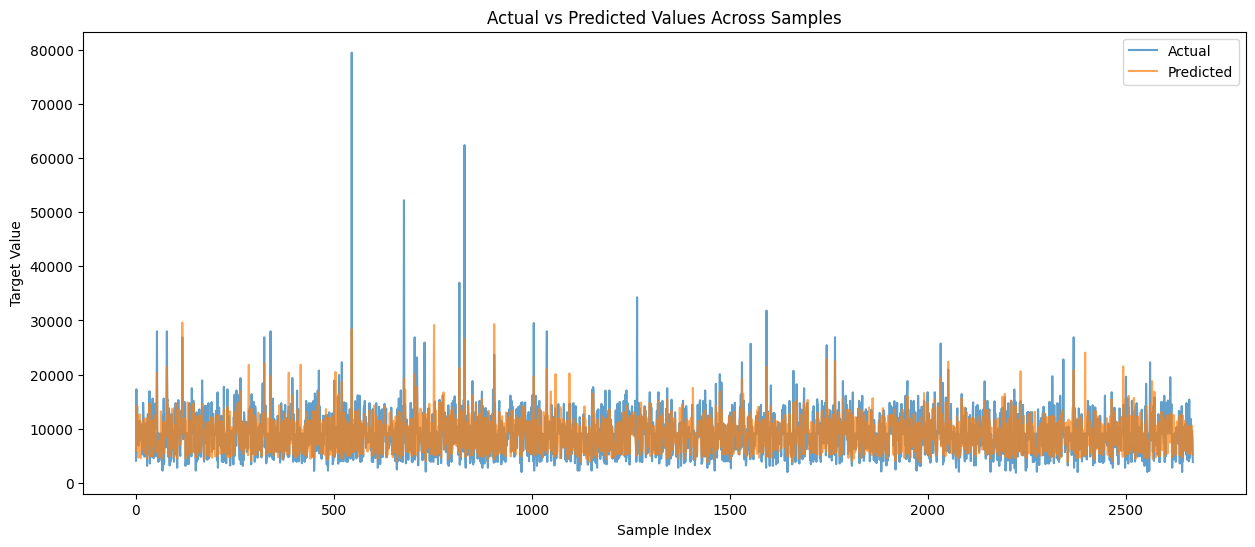

In [60]:
plt.figure(figsize=(15,6))
plt.plot(range(len(y_test)), y_test, label='Actual', alpha=0.7)
plt.plot(range(len(y_test_pred)), y_test_pred, label='Predicted', alpha=0.7)
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("Actual vs Predicted Values Across Samples")
plt.legend()
plt.show()